# Case Vértice Retail: Inteligência Artificial no Atendimento ao Cliente 🚀
**Objetivo da Prova de Conceito (PoC):** Reduzir o tempo de triagem de chamados (SLA atual > 2h), identificar gargalos operacionais e evitar a perda de receita por devoluções e churn de clientes.

Nesta etapa, implementamos um **Classificador Inteligente (Módulo B)** usando IA Generativa. A IA lê a mensagem do cliente, detecta o sentimento e recomenda a ação correta em segundos.

---
### 🛠️ 1. Configuração do Motor de Inteligência Artificial
Nesta célula, inicializamos as conexões seguras com o provedor de IA e preparamos o ambiente de análise de dados. *(Execute apenas uma vez)*

In [33]:
# Instalações silenciosas dos pacotes necessários
%pip install -q pandas requests langchain-litellm litellm seaborn matplotlib pydantic

import os
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from langchain_litellm import ChatLiteLLM
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from enum import Enum
import warnings
warnings.filterwarnings('ignore') # Oculta avisos visuais na apresentação

# ==========================================
# CREDENCIAIS E CONFIGURAÇÕES DA API
# ==========================================
API_KEY = "sk-55eb7f825b6d46779b49ac6138acaee0" # <-------------------- [ATENÇÃO AQUI]
MODEL = "openai/gemini-3-flash-preview"
API_BASE_URL = "https://chat.eloagents.click/api"

os.environ["OPENAI_API_KEY"] = API_KEY
os.environ["OPENAI_API_BASE"] = API_BASE_URL

# Criação do motor de IA com baixa temperatura para garantir consistência nas classificações
llm = ChatLiteLLM(model=MODEL, temperature=0.1, api_base=API_BASE_URL)

print("✅ Ambiente configurado e Motor de IA inicializado com sucesso!")

✅ Ambiente configurado e Motor de IA inicializado com sucesso!


### 🧠 2. O Cérebro da Operação (Regras de Negócio Pydantic)
Em vez de deixar a IA responder em formato livre (o que poderia causar falhas no sistema), utilizamos o **Pydantic** para forçar a IA a devolver uma estrutura de dados perfeita (`JSON`).

Definimos 4 pilares de extração: **Tema, Sentimento, Risco de Churn e Ação Recomendada.**

In [34]:
class TemaOpcoes(str, Enum):
    RASTREIO = "Onde está meu pedido?"
    DEFEITO = "Defeito"
    TROCA = "Troca de Tamanho"
    DUVIDA = "Dúvida Técnica"
    PAGAMENTO = "Pagamento não aprovado"
    ELOGIO = "Elogio"
    OUTROS = "Outros"

class AcaoOpcoes(str, Enum):
    AUTOMACAO = "Automação de Rastreio"
    AUTOMACAO_IMAGEM = "Automação de Troca/Defeito (Reconhecimento de Imagem)"
    RESPOSTA_AUTOMATICA = "Resposta Automática (Elogios/Fidelização)"
    ACAO_FINANCEIRA = "Automação de 2ª Via/Pix"
    FILA_NORMAL = "Fila Humana Normal"
    URGENTE = "Intervenção Humana Urgente"
    BLOQUEIO_SPAM = "Bloqueio Automático (Spam/Loop)"

class SentimentoOpcoes(str, Enum):
    POSITIVO = "Positivo"
    NEUTRO = "Neutro"
    NEGATIVO = "Negativo"
    FURIOSO = "Furioso"

class ChurnOpcoes(str, Enum):
    NENHUM = "Nenhum"
    BAIXO = "Baixo"
    MEDIO = "Médio"
    ALTO = "Alto"

# A GRANDE MUDANÇA: Adicionamos o "raciocinio" como o PRIMEIRO campo
class ClassificacaoTicket(BaseModel):
    raciocinio: str = Field(description="OBRIGATÓRIO INICIAR COM '[Regra X]'. Cite a regra específica do prompt que você está aplicando e explique brevemente.")
    tema: TemaOpcoes = Field(description="O tema principal. Use 'Defeito' APENAS para produtos físicos danificados, não para falhas no site/app.")
    sentimento: SentimentoOpcoes = Field(description="O sentimento do cliente")
    risco_churn: ChurnOpcoes = Field(description="O risco de churn")
    acao_recomendada: AcaoOpcoes = Field(description="O roteamento. NUNCA use 'Automação de 2ª Via/Pix' para cartão recusado, pix já debitado ou erro de app.")

llm_estruturado = llm.with_structured_output(ClassificacaoTicket)

def classificar_ticket(texto_cliente):
    prompt_sistema = """Você é um especialista sênior em Customer Experience da Vértice Retail.
    Siga as REGRAS CRÍTICAS abaixo e documente seu RACIOCÍNIO antes de classificar.

    REGRAS CRÍTICAS:
    1. ELOGIOS: Ação DEVE SER 'Resposta Automática (Elogios/Fidelização)'.
    2. DEFEITO/TROCA: Se rasgou, quebrou ou quer trocar tamanho, Ação DEVE SER 'Automação de Troca/Defeito (Reconhecimento de Imagem)'.
    3. 2ª VIA (Estrito): USE 'Automação de 2ª Via/Pix' APENAS se o cliente relatar boleto/Pix vencido e pedir um novo.
    4. ERRO FINANCEIRO (Proibido 2ª Via): Se disser "Cartão recusado", "Pix debitado mas não aprovado", ou falha ao finalizar pedido no site, USE 'Intervenção Humana Urgente' ou 'Fila Humana Normal'.
    5. LOGÍSTICA (Alerta de Extravio): Dúvidas normais de entrega vão para 'Automação de Rastreio'. MAS se o texto usar a palavra "sumiu", "roubado" ou "extraviado", USE 'Intervenção Humana Urgente'.

    EXEMPLOS DE RACIOCÍNIO E SAÍDA:
    Exemplo 1: 'O boleto venceu e não consigo gerar outro.'
    Saída: raciocinio="Cliente relatou vencimento de boleto, aplica-se a Regra 3.", tema="Pagamento não aprovado", acao_recomendada="Automação de 2ª Via/Pix"

    Exemplo 2: 'Cartão recusado sem motivo, quero entender o que aconteceu.'
    Saída: raciocinio="Ocorreu recusa de cartão, proibido enviar 2ª via (Regra 4). Vai para fila humana.", tema="Pagamento não aprovado", acao_recomendada="Fila Humana Normal"

    Exemplo 3: 'O pedido sumiu no rastreamento preciso de posição urgente.'
    Saída: raciocinio="A palavra 'sumiu' indica possível extravio (Regra 5), exige urgência.", tema="Onde está meu pedido?", acao_recomendada="Intervenção Humana Urgente"
    """

    try:
        resultado = llm_estruturado.invoke([
            SystemMessage(content=prompt_sistema),
            HumanMessage(content=f"Mensagem do cliente: '{texto_cliente}'")
        ])
        return resultado.model_dump()
    except Exception as e:
        return {"raciocinio": "Falha", "tema": "Falha de Conexão", "sentimento": "Desconhecido", "risco_churn": "Pendente", "acao_recomendada": "Fila Humana Normal"}

print("⚙️ Lógica blindada com 'Chain of Thought' (Raciocínio Analítico)!")

⚙️ Lógica blindada com 'Chain of Thought' (Raciocínio Analítico)!


### 📊 3. Prova de Conceito: Processando Dados Reais
Para comprovar o valor financeiro da solução, isolamos uma **amostra randômica de N chamados críticos** da nossa base de mais de 35 mil chamados.
O sistema lerá, interpretará e roteará os tickets em tempo real.

In [35]:
# 1. Leitura e Limpeza dos Dados (Usando Leitura Robusta para evitar quebra de colunas)
file_id = '1trJHdY5EQ2hMo9dDgNXXZM00BFw5rIPn'
url_direta = f'https://drive.google.com/uc?export=download&id={file_id}'
quant_tickets = 100

colunas = [
    'ticket_id', 'customer_id', 'order_id', 'data_abertura',
    'data_fechamento', 'canal_entrada', 'categoria_problema',
    'status_atendimento', 'texto_cliente', 'nota_csat',
    'tempo_primeira_resposta_minutos', 'custo_operacional_ticket'
]

linhas_corrigidas = []

try:
    resposta = requests.get(url_direta)
    resposta.raise_for_status()
    linhas_arquivo = resposta.text.splitlines()

    if len(linhas_arquivo) > 0:
        for linha in linhas_arquivo[1:]:
            linha = linha.strip()
            if not linha: continue

            partes = linha.split(',')

            if len(partes) == 12:
                linhas_corrigidas.append(partes)
            elif len(partes) > 12:
                inicio = partes[:8]
                fim = partes[-3:]
                texto_junto = [",".join(partes[8:-3])]
                linhas_corrigidas.append(inicio + texto_junto + fim)

    df_tickets = pd.DataFrame(linhas_corrigidas, columns=colunas)
    df_tickets = df_tickets.dropna(subset=['texto_cliente'])
    df_tickets = df_tickets[df_tickets['texto_cliente'].str.strip() != '']
    print(f"✅ Base carregada! {len(df_tickets)} tickets disponíveis.")

except Exception as e:
    print(f"❌ ERRO ao baixar do Drive: {e}")

# 2. Amostragem Estratégica (PoC)
# REMOVIDO o random_state=42 para garantir aleatoriedade!
df_amostra = df_tickets.sample(quant_tickets).copy()
print(f"🔄 Processando {quant_tickets} tickets reais pela Triagem Inteligente...\n")

# 3. Execução do Modelo
resultados = []
for index, row in df_amostra.iterrows():
    texto = str(row['texto_cliente'])
    classificacao = classificar_ticket(texto)

    def extrair_valor(valor):
        if hasattr(valor, 'value'): return valor.value
        if isinstance(valor, str): return valor
        return 'Erro/Não Identificado'

    resultados.append({
        "Ticket_ID": row['ticket_id'],
        "Texto_Original": texto,
        "Raciocínio_IA": classificacao.get('raciocinio'),
        "Tema_IA": extrair_valor(classificacao.get('tema')),
        "Sentimento_IA": extrair_valor(classificacao.get('sentimento')),
        "Risco_Churn_IA": extrair_valor(classificacao.get('risco_churn')),
        "Ação_Recomendada_IA": extrair_valor(classificacao.get('acao_recomendada'))
    })

# 4. Formatação Visual para a Diretoria
df_resultado_ia = pd.DataFrame(resultados)
pd.set_option('display.max_colwidth', None)

def colorir_risco(val):
    cor = '#ff9999' if val == 'Alto' else '#ffcc99' if val == 'Médio' else '#99ff99' if val == 'Baixo' else '#e8f4f8' if val == 'Nenhum' else ''
    return f'background-color: {cor}; color: black'

display(df_resultado_ia.style.map(colorir_risco, subset=['Risco_Churn_IA']))

✅ Base carregada! 35840 tickets disponíveis.
🔄 Processando 100 tickets reais pela Triagem Inteligente...



,Ticket_ID,Texto_Original,Raciocínio_IA,Tema_IA,Sentimento_IA,Risco_Churn_IA,Ação_Recomendada_IA
0,TKT-016404,O produto parou de funcionar em dois dias. Absurdo.,"[Regra Tema: Defeito] O cliente relata que o produto físico parou de funcionar em apenas dois dias, o que se enquadra na definição de defeito técnico de item físico, conforme a orientação de não usar este tema para falhas de site/app.",Defeito,Negativo,Médio,Automação de Troca/Defeito (Reconhecimento de Imagem)
1,TKT-023124,Tentei pagar três vezes e não consigo finalizar o pedido.,"[Regra Pagamento não aprovado] O cliente relata uma falha crítica no processo de checkout após múltiplas tentativas (três vezes), o que caracteriza um problema de processamento de pagamento. O sentimento é negativo devido à frustração da repetição sem sucesso, e o risco de churn é médio, pois a impossibilidade de pagar impede a conversão imediata. Conforme a restrição de não utilizar automação de 2ª via para erros de pagamento ou recusas, o caso é direcionado para a fila humana.",Pagamento não aprovado,Negativo,Médio,Fila Humana Normal
2,TKT-018253,Cartão recusado sem motivo quero entender o que aconteceu.,"[Regra Pagamento] O cliente relata que o cartão foi recusado e solicita uma explicação sobre o ocorrido. Seguindo a restrição explícita de não utilizar 'Automação de 2ª Via/Pix' para casos de cartão recusado, e considerando que o cliente busca entender o motivo técnico, o atendimento deve ser direcionado para um consultor humano.",Pagamento não aprovado,Negativo,Médio,Fila Humana Normal
3,TKT-025614,Como solicito a troca? O tamanho P está pequeno demais.,"[Regra Tema] O cliente solicita explicitamente a troca devido ao tamanho ('tamanho P está pequeno demais'), o que se enquadra no tema 'Troca de Tamanho' e permite o uso da 'Automação de Troca/Defeito'.",Troca de Tamanho,Neutro,Baixo,Automação de Troca/Defeito (Reconhecimento de Imagem)
4,TKT-028953,Fiz o pedido há 10 dias e ainda não chegou o que está acontecendo?,"[Regra Onde está meu pedido?] O cliente questiona o status de uma entrega que está atrasada há 10 dias, o que direciona o tema para rastreio e o sentimento para negativo devido à frustração com o prazo.",Onde está meu pedido?,Negativo,Médio,Automação de Rastreio
5,TKT-010095,Meu rastreio não atualiza desde terça. Alguém me ajuda?,"[Regra de Classificação de Tema] O cliente utiliza o termo 'rastreio' e expressa dúvida sobre a localização/status da entrega, o que caracteriza o tema de acompanhamento de pedido e permite o uso de ferramentas de rastreamento automático.",Onde está meu pedido?,Neutro,Baixo,Automação de Rastreio
6,TKT-005705,Meu pagamento não foi aprovado mas o valor foi debitado.,"[Regra de Roteamento] O cliente relata que o valor foi debitado indevidamente após uma recusa de pagamento. Seguindo a diretriz de nunca utilizar automação de 2ª via/Pix para casos onde o valor já foi debitado ou houve erro de processamento, o caso exige análise de um atendente para verificação junto ao gateway de pagamento.",Pagamento não aprovado,Negativo,Médio,Fila Humana Normal
7,TKT-016386,Preciso trocar o tamanho M pelo G como faço?,"[Regra Troca de Tamanho] O cliente solicita explicitamente a substituição de um produto por outro de tamanho diferente, o que define o tema e direciona para o fluxo de automação de trocas.",Troca de Tamanho,Neutro,Baixo,Automação de Troca/Defeito (Reconhecimento de Imagem)
8,TKT-022310,Cadê meu produto? Já passou da data prevista.,"[Regra de Classificação de Intenção] O cliente questiona explicitamente a localização do produto e reclama do descumprimento do prazo de entrega, o que enquadra a mensagem no tema de rastreio e indica insatisfação.",Onde está meu pedido?,Negativo,Médio,Automação de Rastreio
9,TKT-002623,Quero fazer uma troca o produto não serviu.,"[Regra 1] O cliente solicita explicitamente uma troca informando que o produto 'não serviu', o que enquadra a solicitação no tema de Troca de Tamanho. O tom da mensagem é direto e objetivo, caracte

---
---

### 📈 4. Visão Executiva e Impacto de Negócio
O gráfico abaixo resume as ações recomendadas pelo sistema.
**Resultado Imediato:**
* Casos de **Automação de Rastreio** (WISMO) nunca chegam aos analistas. Custo cortado.
* Casos **Urgentes** (Furiosos + Defeito) furam a fila, garantindo a retenção da receita.

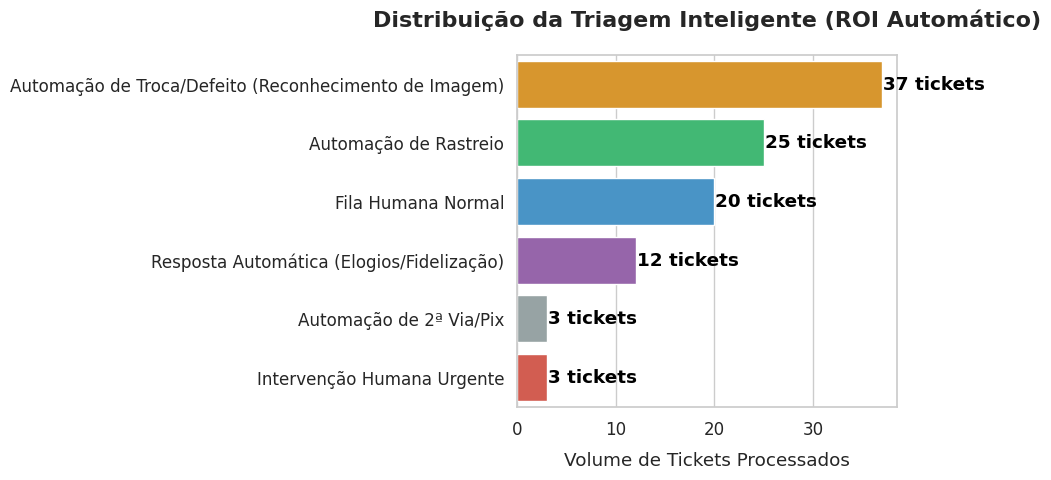

In [36]:
# Configuração visual do gráfico executivo
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 5))

contagem_acoes = df_resultado_ia['Ação_Recomendada_IA'].value_counts()

# Criando uma paleta dinâmica com as novas categorias
cores_finais = []
for acao in contagem_acoes.index:
    if acao == 'Intervenção Humana Urgente':
        cores_finais.append('#e74c3c') # Vermelho (Alerta)
    elif acao == 'Fila Humana Normal':
        cores_finais.append('#3498db') # Azul (Padrão)
    elif acao == 'Automação de Rastreio':
        cores_finais.append('#2ecc71') # Verde (Eficiência WISMO)
    elif acao == 'Resposta Automática (Elogios/Fidelização)':
        cores_finais.append('#9b59b6') # Roxo (Monetização/Upsell)
    elif acao == 'Automação de Troca/Defeito (Reconhecimento de Imagem)':
        cores_finais.append('#f39c12') # Laranja (Redução de Fricção)
    elif acao == 'Bloqueio Automático (Spam/Loop)':
        cores_finais.append('#34495e') # Cinza Escuro (Defesa)
    else:
        cores_finais.append('#95a5a6')

ax = sns.barplot(
    y=contagem_acoes.index,
    x=contagem_acoes.values,
    hue=contagem_acoes.index,
    palette=cores_finais,
    legend=False
)

plt.title('Distribuição da Triagem Inteligente (ROI Automático)', fontweight='bold', pad=20, fontsize=16)
plt.xlabel('Volume de Tickets Processados', labelpad=10)
plt.ylabel('')
plt.xlim(0, contagem_acoes.max() + 1.5)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.1, p.get_y() + p.get_height()/2.,
                f'{int(width)} tickets',
                ha="left", va="center", color='black', fontweight='bold')

plt.tight_layout()
plt.show()

---
### 🎮 5. Teste ao Vivo (Simulador Interativo)
Digite qualquer reclamação ou dúvida na caixa de texto abaixo e veja como a nossa Inteligência Artificial toma a decisão de triagem em tempo real!

In [37]:
#@title 💬 Simulador de Atendimento ao Vivo { run: "auto" }

# A linha abaixo cria uma caixa de texto interativa no lado direito do Colab!
mensagem_ao_vivo = "Meu pedido veio com uns riscados" #@param {type:"string"}

import time

# Pequeno suspense para efeito de apresentação
print("Processando a mensagem do cliente pela IA...")
time.sleep(1)

# Chama a nossa função de triagem blindada
classificacao_ao_vivo = classificar_ticket(mensagem_ao_vivo)

# Função rápida para extrair a string do Enum
def extrair_valor_simulador(valor):
    if hasattr(valor, 'value'): return valor.value
    if isinstance(valor, str): return valor
    return 'Erro'

# Extrai os valores
tema = extrair_valor_simulador(classificacao_ao_vivo.get('tema', 'Erro'))
sent = extrair_valor_simulador(classificacao_ao_vivo.get('sentimento', 'Erro'))
risco = extrair_valor_simulador(classificacao_ao_vivo.get('risco_churn', 'Erro'))
acao = extrair_valor_simulador(classificacao_ao_vivo.get('acao_recomendada', 'Erro'))

# Define um alerta visual dependendo da ação
icone_acao = "🚨" if acao == "Intervenção Humana Urgente" else "🤖" if acao == "Automação de Rastreio" else "👨‍💻"

# Imprime o resultado formatado como um painel de sistema
print("-" * 50)
print("📊 RESULTADO DA TRIAGEM INTELIGENTE:")
print("-" * 50)
print(f"📋 Tema Detectado  : {tema}")
print(f"🎭 Sentimento      : {sent}")
print(f"⚠️ Risco de Churn  : {risco}")
print("-" * 50)
print(f"{icone_acao} AÇÃO RECOMENDADA: {acao.upper()}")
print("-" * 50)

Processando a mensagem do cliente pela IA...
--------------------------------------------------
📊 RESULTADO DA TRIAGEM INTELIGENTE:
--------------------------------------------------
📋 Tema Detectado  : Defeito
🎭 Sentimento      : Negativo
⚠️ Risco de Churn  : Baixo
--------------------------------------------------
👨‍💻 AÇÃO RECOMENDADA: AUTOMAÇÃO DE TROCA/DEFEITO (RECONHECIMENTO DE IMAGEM)
--------------------------------------------------


📊 RELATÓRIO EXECUTIVO DE ROI (Baseado em Dados Reais do ERP)
Volume Processado na Amostra: 100 tickets
Tickets Defletidos (Zero-Touch): 77 (77.0%)
-----------------------------------------------------------------
Custo Operacional Original (Sem IA): R$ 1,437.00
Custo Operacional Novo (Com IA): R$ 315.00
Custo da API (Tokens LLM): R$ 5.00
💰 ECONOMIA LÍQUIDA NA AMOSTRA: R$ 1,122.00
📅 Volume Médio Mensal: 995.6 tickets/mês
💰 Economia Estimada por Mês: R$ 11,170.13
📈 Economia Estimada por Ano: R$ 134,041.60
🎯 Economia Total no Período (3 Anos): R$ 402,124.80



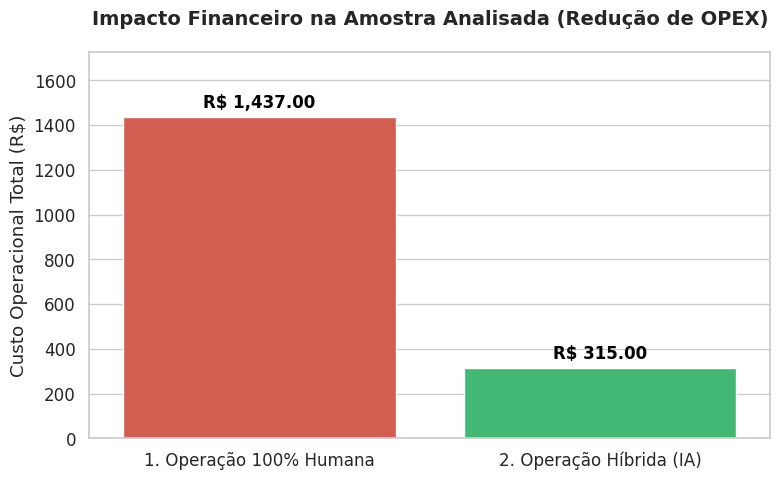

In [41]:
# ==========================================
# 1. CRUZAMENTO CORRETO COM A BASE (df_tickets)
# ==========================================
# Garantimos que a coluna de custo está presente e no formato numérico correto
if 'custo_operacional_ticket' not in df_resultado_ia.columns:
    df_resultado_ia = df_resultado_ia.merge(
        df_tickets[['ticket_id', 'custo_operacional_ticket']],
        left_on='Ticket_ID',
        right_on='ticket_id',
        how='left'
    )

# Converter a coluna de custo para tipo numérico (evita erros de soma de strings)
df_resultado_ia['custo_operacional_ticket'] = pd.to_numeric(
    df_resultado_ia['custo_operacional_ticket'], errors='coerce'
).fillna(0)

# ==========================================
# 2. VARIÁVEIS DE CUSTO DA IA
# ==========================================
CUSTO_POR_TICKET_IA = 0.05  # Custo estimado de tokens por requisição na API

# ==========================================
# 3. MOTOR FINANCEIRO BASEADO NOS DADOS REAIS
# ==========================================
volume_total = len(df_resultado_ia)

# Custo Status Quo (100% Humano) somando a coluna real da amostra processada
custo_total_antigo = df_resultado_ia['custo_operacional_ticket'].sum()

# Definimos quais ações não precisam de intervenção humana (automações)
acoes_automatizadas = [
    'Automação de Rastreio',
    'Automação de Troca/Defeito (Reconhecimento de Imagem)',
    'Automação de 2ª Via/Pix',
    'Resposta Automática (Elogios/Fidelização)',
    'Bloqueio Automático (Spam/Loop)'
]

# Filtramos apenas os tickets que a IA desviou da fila humana
df_defletido = df_resultado_ia[df_resultado_ia['Ação_Recomendada_IA'].isin(acoes_automatizadas)]
volume_defletido = len(df_defletido)
taxa_deflexao = volume_defletido / volume_total if volume_total > 0 else 0

# A economia bruta é a soma do custo operacional dos tickets que foram resolvidos por IA
economia_bruta = df_defletido['custo_operacional_ticket'].sum()

# Calculamos o custo tecnológico (API da IA para ler todos os tickets da amostra)
custo_tecnologia_ia = volume_total * CUSTO_POR_TICKET_IA

# Resultados Finais da Amostra
economia_liquida = economia_bruta - custo_tecnologia_ia
custo_total_novo = custo_total_antigo - economia_liquida

# ==========================================
# 4. DASHBOARD EXECUTIVO
# ==========================================
print("📊 RELATÓRIO EXECUTIVO DE ROI (Baseado em Dados Reais do ERP)")
print("="*65)
print(f"Volume Processado na Amostra: {volume_total:,} tickets")
print(f"Tickets Defletidos (Zero-Touch): {volume_defletido:,} ({taxa_deflexao*100:.1f}%)")
print("-" * 65)
print(f"Custo Operacional Original (Sem IA): R$ {custo_total_antigo:,.2f}")
print(f"Custo Operacional Novo (Com IA): R$ {custo_total_novo:,.2f}")
print(f"Custo da API (Tokens LLM): R$ {custo_tecnologia_ia:,.2f}")
print("="*65)
print(f"💰 ECONOMIA LÍQUIDA NA AMOSTRA: R$ {economia_liquida:,.2f}")

# ==========================================
# PROJEÇÃO TEMPORAL CORRETA (Base: 3 anos / 36 meses)
# ==========================================
total_tickets_historico = 35840
meses_historico = 36

# Média de tickets mensais
tickets_por_mes = total_tickets_historico / meses_historico

# Economia gerada por cada ticket na amostra
economia_por_ticket = 1122.00 / 100 # R$ 1.122,00 economizados em 100 tickets

# Projeções financeiras
economia_mensal = tickets_por_mes * economia_por_ticket
economia_anual = economia_mensal * 12
economia_total_3_anos = economia_mensal * meses_historico

print(f"📅 Volume Médio Mensal: {tickets_por_mes:,.1f} tickets/mês")
print(f"💰 Economia Estimada por Mês: R$ {economia_mensal:,.2f}")
print(f"📈 Economia Estimada por Ano: R$ {economia_anual:,.2f}")
print(f"🎯 Economia Total no Período (3 Anos): R$ {economia_total_3_anos:,.2f}")
print("=" * 65 + "\n")

# ==========================================
# 5. GRÁFICO DE IMPACTO FINANCEIRO
# ==========================================
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(8, 5))

dados_grafico = pd.DataFrame({
    'Cenário': ['1. Operação 100% Humana', '2. Operação Híbrida (IA)'],
    'Custo (R$)': [custo_total_antigo, custo_total_novo]
})

cores = ['#e74c3c', '#2ecc71'] # Vermelho (Alto custo) e Verde (Eficiente)
barras = sns.barplot(x='Cenário', y='Custo (R$)', data=dados_grafico, palette=cores, ax=ax)

for p in barras.patches:
    ax.annotate(f'R$ {p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', xytext=(0, 10),
                textcoords='offset points')

plt.title('Impacto Financeiro na Amostra Analisada (Redução de OPEX)', fontweight='bold', pad=20, fontsize=14)
plt.ylabel('Custo Operacional Total (R$)')
plt.xlabel('')
plt.ylim(0, custo_total_antigo * 1.2)
plt.tight_layout()
plt.show()